# King County House Price Prediction

## Regression and classification models for residential real estate, built with scikit-learn and Keras

## Table of Content

1. [Executive Summary](#cell_Summary)

2. [Data Preprocessing](#cell_Preprocessing)

3. [Predictive Modeling](#cell_model)

4. [Experiments Report](#cell_report)


<a id = "cell_Summary"></a>
## 1. Executive Summary

King County Assessor records cover more than 21,613 residential sales in the Seattle area of Washington State. This report uses that data set to build models for two related problems: estimating the exact sale price of a house, and sorting houses into a High_Price or Low_Price band around a $450,000 threshold.

For price estimation, a linear regression model was compared against three neural network designs that varied in depth, activation function and optimizer, rather than testing a single architecture. Linear regression reached an R squared of 0.69 on the test set, with a mean absolute error of about $125,000. The best performing network, a two layer design using tanh and relu activations trained with RMSprop, brought the error down to about $80,000 and reached an R squared of 0.85. A shallow relu network and a deeper network with dropout both landed in between these two results. The size of that gap suggests that price in this market is driven by interactions between features such as location, living area and construction grade that a straight line model cannot represent well.

For the classification problem, a random forest and a multilayer perceptron were each tested in three configurations. Every random forest setting outperformed every neural network setting. The strongest random forest, built from 100 trees with no depth limit, reached 91.4% accuracy on the test set, while the best multilayer perceptron, using two hidden layers, reached 90.7%. The random forest also produces a ranked list of which attributes separate High_Price from Low_Price homes, and latitude, living area and the county grade score come out on top.

Taken together, both halves of this report point the same way. Linear regression is a reasonable starting point, but models that can capture nonlinear feature interactions, whether a tuned neural network or a random forest, perform noticeably better on this data set for both price estimation and price band classification. A real estate business could use the tuned neural network to generate a first price estimate for a new listing, then use the random forest and its feature importance ranking to show an agent or seller which attributes are pushing that estimate up or down.

<a id = "cell_Preprocessing"></a>
## 2. Data Preprocessing

Loading Python libraries.

In [1]:
from __future__ import print_function
import os
import math
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2023)

Loading scikit learn modules and metrics.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Pandas display options, so wide tables are not truncated.

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

Loading the data set and checking its size.

In [4]:
hp_df = pd.read_csv("data/Part1_house_price.csv")
hp_df.set_index('id', inplace=True)
print('Number of records read:', len(hp_df))
print('Number of columns:', hp_df.shape[1])
hp_df.head(10)

Number of records read: 21613
Number of columns: 20


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113


Column data types and a check for missing values. Neither King County nor Kaggle report any gaps in this extract, so no imputation is required.

In [5]:
print(hp_df.dtypes)
print()
print(hp_df.isnull().sum())

date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


The `date` column is a sale timestamp, not a usable numeric feature on its own. Rather than dropping it outright, two new columns are engineered from it and from the existing `yr_built` and `yr_renovated` columns:

* `house_age`: the number of years between construction and the sale date. Age tends to matter more to buyers than the raw construction year.
* `is_renovated`: a flag set to 1 when King County has a renovation year on file, and 0 otherwise.

The original `date`, `yr_built` and `yr_renovated` columns are then dropped, since their information now lives in the two new columns.

In [6]:
sale_year = pd.to_datetime(hp_df['date'].str[:8]).dt.year
hp_df['house_age'] = sale_year - hp_df['yr_built']
hp_df['is_renovated'] = (hp_df['yr_renovated'] > 0).astype(int)
hp_df.drop(['date', 'yr_built', 'yr_renovated'], axis=1, inplace=True)

hp_df.describe(include='all')

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,is_renovated
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,43.317818,0.042289
std,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,53.505026,0.138564,0.140828,685.391304,27304.179631,29.375493,0.201253
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,-1.000000,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,18.000000,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,40.000000,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,63.000000,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,115.000000,1.000000


A quick look at how strongly each attribute correlates with price helps confirm that the engineered columns are worth keeping and points to the features that later models are expected to lean on.

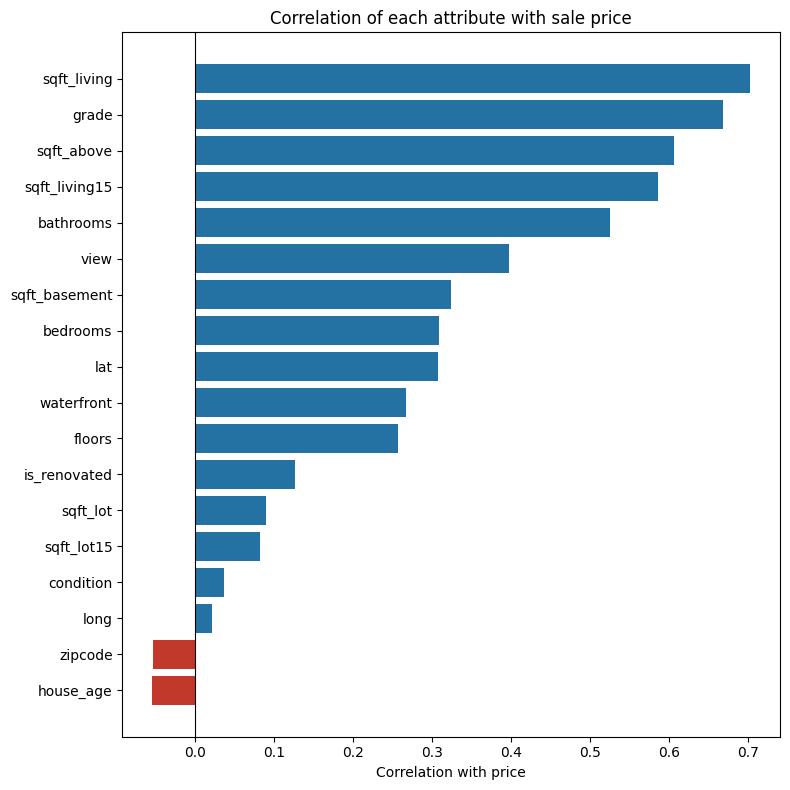

In [7]:
price_corr = hp_df.corr(numeric_only=True)['price'].drop('price').sort_values()

plt.figure(figsize=(8, 8))
colors = ['#c0392b' if v < 0 else '#2471a3' for v in price_corr.values]
plt.barh(price_corr.index, price_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with price')
plt.title('Correlation of each attribute with sale price')
plt.tight_layout()
plt.show()

`sqft_living`, `grade` and `sqft_living15` (the average living area of the 15 nearest homes) show the strongest positive relationship with price, which matches what a real estate agent would expect. `zipcode` sits close to zero here because it is a location code rather than an ordered quantity, so its raw correlation with price understates how useful it is once a model can split on individual zip codes.

The price threshold used for the classification task is applied now, so both parts of the report work from the same labelled data set.

In [8]:
hp_df['High_Price'] = (hp_df['price'] >= 450000).astype(int)
print(hp_df['High_Price'].value_counts())
print('Share of High_Price homes: {:.1%}'.format(hp_df['High_Price'].mean()))

High_Price
1    10921
0    10692
Name: count, dtype: int64
Share of High_Price homes: 50.5%


The data is split into a 70% training set and a 30% test set, a common choice for this kind of tabular data set, using a fixed random seed so the split can be reproduced.

In [9]:
hp_train, hp_test = train_test_split(hp_df, test_size=0.30, random_state=2023)

print('Size of training set:', len(hp_train))
print('Size of testing set:', len(hp_test))

Size of training set: 15129
Size of testing set: 6484


For the price estimation task, the target is `price` and `High_Price` is removed from the inputs, since it is a direct function of the target and would leak the answer.

In [10]:
label_col = 'price'
hp_y_train = hp_train[[label_col]]
hp_x_train = hp_train.drop([label_col, 'High_Price'], axis=1)
hp_y_test = hp_test[[label_col]]
hp_x_test = hp_test.drop([label_col, 'High_Price'], axis=1)

print('Training features shape:', hp_x_train.shape)
print('Testing features shape:', hp_x_test.shape)

Training features shape: (15129, 18)
Testing features shape: (6484, 18)


A MinMax scaler is fitted on the training features only, then applied to both the training and test sets, so no information from the test set leaks into the scaling step.

In [11]:
scaler = MinMaxScaler(feature_range=(0, 1), copy=True).fit(hp_x_train)
hp_x_train_scaled = pd.DataFrame(scaler.transform(hp_x_train),
                            columns=hp_x_train.columns, index=hp_x_train.index)
hp_x_test_scaled = pd.DataFrame(scaler.transform(hp_x_test),
                            columns=hp_x_test.columns, index=hp_x_test.index)

print('X train scaled min =', round(hp_x_train_scaled.min().min(), 4), '; max =', round(hp_x_train_scaled.max().max(), 4))
print('X test scaled min =', round(hp_x_test_scaled.min().min(), 4), '; max =', round(hp_x_test_scaled.max().max(), 4))

X train scaled min = 0.0 ; max = 1.0
X test scaled min = -0.0001 ; max = 3.0


In [12]:
hp_x_test_scaled.head(10)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,is_renovated
id,,,,,,,,,,,,,,,,,,
3293700496,0.363636,0.21875,0.117736,0.006124,0.0,0.0,0.0,1.00,0.500000,0.088816,0.155602,0.666667,0.952549,0.136213,0.320255,0.009248,0.508621,0.0
662310620,0.272727,0.31250,0.193208,0.010302,0.4,0.0,0.0,0.50,0.666667,0.280702,0.000000,0.111111,0.207335,0.144518,0.421786,0.010244,0.155172,0.0
4154304740,0.272727,0.34375,0.187925,0.005669,0.2,0.0,0.0,0.75,0.583333,0.173246,0.188797,0.590909,0.655139,0.206811,0.223886,0.007637,0.887931,0.0
8645530010,0.272727,0.25000,0.083774,0.005827,0.0,0.0,0.0,0.50,0.500000,0.094298,0.051867,0.287879,0.497989,0.286545,0.244536,0.008561,0.310345,0.0
1257201095,0.181818,0.12500,0.058113,0.004741,0.0,0.0,0.0,0.50,0.500000,0.084430,0.000000,0.515152,0.833199,0.157807,0.229048,0.003999,0.931034,0.0
809002290,0.363636,0.37500,0.147170,0.004638,0.2,0.0,0.0,0.75,0.583333,0.107456,0.201245,0.545455,0.773685,0.140365,0.316813,0.004197,0.870690,0.0
3876540600,0.272727,0.28125,0.123774,0.006521,0.0,0.0,0.0,0.50,0.500000,0.129386,0.095436,0.010101,0.171304,0.182724,0.191189,0.008794,0.275862,0.0
2658000215,0.181818,0.12500,0.040000,0.003659,0.0,0.0,0.0,1.00,0.416667,0.058114,0.000000,0.590909,0.601415,0.205980,0.144726,0.006238,0.517241,0.0
222069058,0.272727,0.40625,0.147925,0.051493,0.0,0.0,0.0,0.50,0.666667,0.214912,0.000000,0.186869,0.432202,0.419435,0.406298,0.097284,0.086207,0.0


<a id = "cell_model"></a>
## 3. Predictive Modeling

### 3.1 Part A: Estimating house price with regression

Two families of regression model are compared here: a linear regression baseline, and a set of feed forward neural networks. Rather than tuning a single network by trial and error, three architectures are trained under the same conditions so the comparison itself becomes part of the evidence.

Loading TensorFlow and Keras components.

In [13]:
import tensorflow as tf
from tensorflow.keras import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, Nadam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(2023)

Linear regression baseline.

In [14]:
lm = LinearRegression()
lm.fit(hp_x_train_scaled, hp_y_train)
linear_predictions = lm.predict(hp_x_test_scaled)

linear_mse = mean_squared_error(hp_y_test, linear_predictions)
linear_mae = mean_absolute_error(hp_y_test, linear_predictions)
linear_r2 = r2_score(hp_y_test, linear_predictions)

print(f"Linear Regression MSE: {linear_mse:,.2f}")
print(f"Linear Regression MAE: {linear_mae:,.2f}")
print(f"Linear Regression R2:  {linear_r2:.4f}")

Linear Regression MSE: 37,594,768,173.93
Linear Regression MAE: 125,005.99
Linear Regression R2:  0.6928


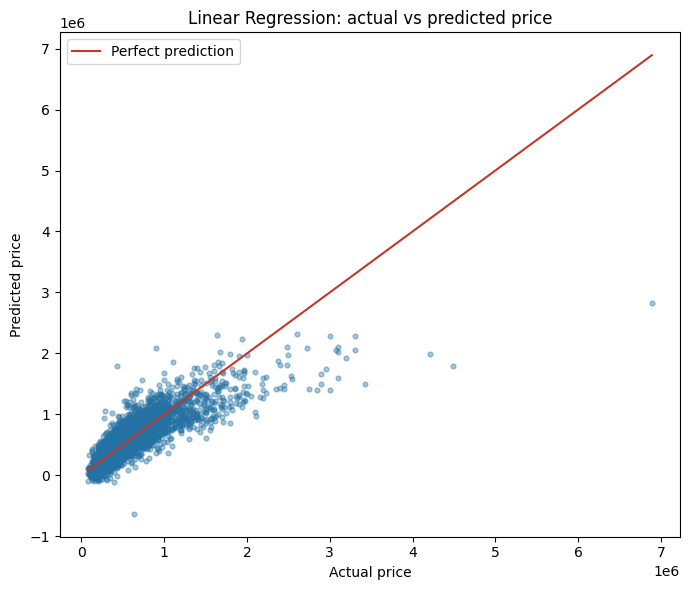

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(hp_y_test, linear_predictions, color='#2471a3', alpha=0.4, s=12)
lims = [hp_y_test['price'].min(), hp_y_test['price'].max()]
plt.plot(lims, lims, color='#c0392b', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Linear Regression: actual vs predicted price')
plt.legend()
plt.tight_layout()
plt.show()

Converting the scaled data frames to NumPy arrays for Keras.

In [16]:
arr_hp_x_train = np.array(hp_x_train_scaled)
arr_hp_y_train = np.array(hp_y_train)
arr_hp_x_test = np.array(hp_x_test_scaled)
arr_hp_y_test = np.array(hp_y_test)

print('Training samples:', arr_hp_x_train.shape[0])
print('Testing samples:', arr_hp_x_test.shape[0])
print('Number of input features:', arr_hp_x_train.shape[1])

Training samples: 15129
Testing samples: 6484
Number of input features: 18


A small builder function turns a configuration dictionary into a compiled Keras model, so the three architectures below share the same training and evaluation code and differ only in their structure.

In [17]:
def build_regression_model(config, x_size):
    m = Sequential(name=config['name'])
    for i, (units, activation) in enumerate(config['layers']):
        if i == 0:
            m.add(Dense(units, activation=activation, input_shape=(x_size,)))
        else:
            m.add(Dense(units, activation=activation))
        if config.get('dropout'):
            m.add(Dropout(config['dropout']))
    m.add(Dense(1))
    m.compile(loss='mean_squared_error', optimizer=config['optimizer'], metrics=[metrics.mae])
    return m

Three configurations are tested:

1. **nn_shallow**: two relu layers (64, 32 units), Adam optimizer. A lightweight baseline network.
2. **nn_wide_tanh**: a tanh layer followed by a relu layer (100, 80 units), RMSprop optimizer. A wider network with a mixed activation setup.
3. **nn_deep_dropout**: three relu layers (128, 64, 32 units) with 20% dropout after each, Nadam optimizer. A deeper network with regularisation to guard against overfitting.

Each model trains for up to 80 epochs with early stopping on validation loss, so slower or faster converging architectures are not penalised or favoured by a fixed epoch count.

In [18]:
regression_configs = [
    {'name': 'nn_shallow', 'layers': [(64, 'relu'), (32, 'relu')],
     'optimizer': Adam(learning_rate=0.01), 'dropout': None},
    {'name': 'nn_wide_tanh', 'layers': [(100, 'tanh'), (80, 'relu')],
     'optimizer': RMSprop(learning_rate=0.005), 'dropout': None},
    {'name': 'nn_deep_dropout', 'layers': [(128, 'relu'), (64, 'relu'), (32, 'relu')],
     'optimizer': Nadam(learning_rate=0.005), 'dropout': 0.2},
]

regression_results = []
regression_models = {}
regression_predictions = {}

for cfg in regression_configs:
    tf.random.set_seed(2023)
    model = build_regression_model(cfg, arr_hp_x_train.shape[1])
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    history = model.fit(arr_hp_x_train, arr_hp_y_train,
                         batch_size=64, epochs=80, shuffle=True, verbose=0,
                         validation_data=(arr_hp_x_test, arr_hp_y_test),
                         callbacks=[early_stop])
    predictions = model.predict(arr_hp_x_test, verbose=0)

    regression_results.append({
        'model': cfg['name'],
        'hidden layers': str([u for u, _ in cfg['layers']]),
        'epochs trained': len(history.history['loss']),
        'MSE': mean_squared_error(arr_hp_y_test, predictions),
        'MAE': mean_absolute_error(arr_hp_y_test, predictions),
        'R2': r2_score(arr_hp_y_test, predictions),
    })
    regression_models[cfg['name']] = model
    regression_predictions[cfg['name']] = predictions

regression_results_df = pd.DataFrame(regression_results).set_index('model')
regression_results_df

/private/tmp/claude-501/-Users-ahmet-Workings/2007ebe3-9178-48bd-b9b4-1db5b31e988f/scratchpad/mis780_venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/private/tmp/claude-501/-Users-ahmet-Workings/2007ebe3-9178-48bd-b9b4-1db5b31e988f/scratchpad/mis780_venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/private/tmp/claude-501/-Users-ahmet-Workings/2007ebe3-9178-48bd-b9b4-1db5b31e988f/scratchpad/mis780_venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,hidden layers,epochs trained,MSE,MAE,R2
model,,,,,
nn_shallow,"[64, 32]",80,2.760589e+10,106248.352718,0.774422
nn_wide_tanh,"[100, 80]",80,1.814655e+10,79482.719213,0.851718
nn_deep_dropout,"[128, 64, 32]",80,2.182768e+10,94560.733098,0.821638


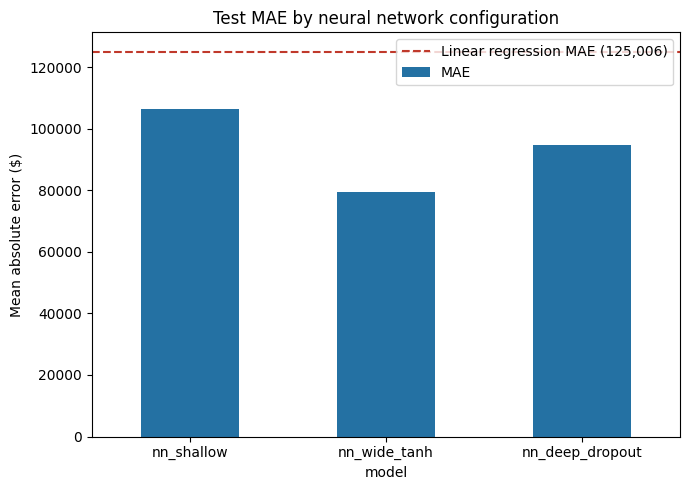

In [19]:
ax = regression_results_df['MAE'].plot(kind='bar', color='#2471a3', figsize=(7, 5))
ax.axhline(linear_mae, color='#c0392b', linestyle='--', label=f'Linear regression MAE ({linear_mae:,.0f})')
plt.ylabel('Mean absolute error ($)')
plt.title('Test MAE by neural network configuration')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

The wide network with tanh and relu layers, `nn_wide_tanh`, has the lowest test MAE of the three configurations and is carried forward as the neural network result for this task. Its predictions against the actual test prices are plotted below, together with the correlation between predicted and actual values.

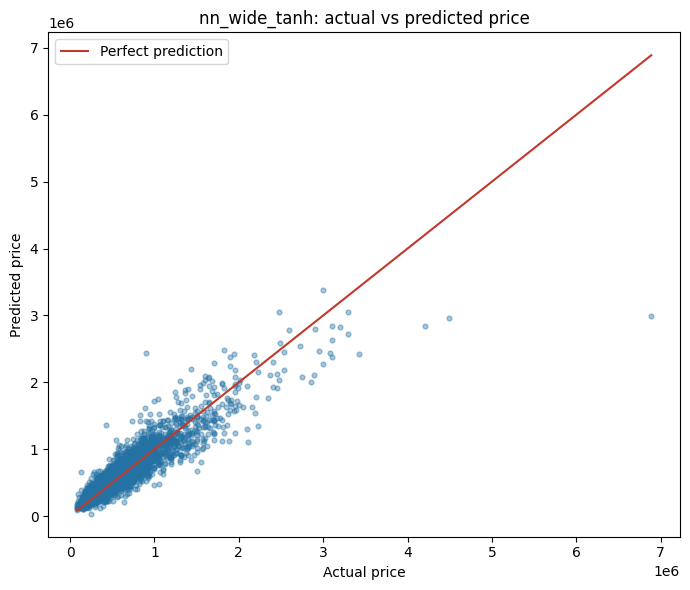

Correlation between true and predicted values for nn_wide_tanh: 0.924
Test MAE: 79,482.72
Test R2: 0.8517


In [20]:
best_regression_name = regression_results_df['MAE'].idxmin()
best_predictions = regression_predictions[best_regression_name]

plt.figure(figsize=(7, 6))
plt.scatter(arr_hp_y_test, best_predictions, color='#2471a3', alpha=0.4, s=12)
lims = [arr_hp_y_test.min(), arr_hp_y_test.max()]
plt.plot(lims, lims, color='#c0392b', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title(f'{best_regression_name}: actual vs predicted price')
plt.legend()
plt.tight_layout()
plt.show()

corr_result = np.corrcoef(arr_hp_y_test.reshape(-1), best_predictions.reshape(-1))
print(f'Correlation between true and predicted values for {best_regression_name}: {corr_result[0, 1]:.3f}')
print(f'Test MAE: {regression_results_df.loc[best_regression_name, "MAE"]:,.2f}')
print(f'Test R2: {regression_results_df.loc[best_regression_name, "R2"]:.4f}')

### 3.2 Part B: Classifying High_Price vs Low_Price houses

The `High_Price` label created earlier (1 for sales at $450,000 or more, 0 otherwise) is used directly, so a separate `Low_Price` column is not needed. It would only ever hold the opposite value of `High_Price` and would add nothing a model could use.

A random forest and a multilayer perceptron are each tested in three configurations, so the comparison between model types is not decided by a single arbitrary setting on either side.

In [21]:
X = hp_df.drop(columns=['price', 'High_Price'])
y = hp_df['High_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=2023, stratify=y)

class_scaler = StandardScaler()
X_train_scaled = class_scaler.fit_transform(X_train)
X_test_scaled = class_scaler.transform(X_test)

print('Training rows:', X_train_scaled.shape[0])
print('Testing rows:', X_test_scaled.shape[0])
print('Share of High_Price in training set: {:.1%}'.format(y_train.mean()))
print('Share of High_Price in testing set: {:.1%}'.format(y_test.mean()))

Training rows: 15129
Testing rows: 6484
Share of High_Price in training set: 50.5%
Share of High_Price in testing set: 50.5%


Three random forest settings are compared: 100 trees with unlimited depth, 300 trees with unlimited depth, and 300 trees capped at a depth of 10. This checks whether adding more trees or restricting depth changes performance on this data set.

In [22]:
rf_configs = [
    {'name': 'rf_100_trees', 'n_estimators': 100, 'max_depth': None},
    {'name': 'rf_300_trees', 'n_estimators': 300, 'max_depth': None},
    {'name': 'rf_300_trees_depth10', 'n_estimators': 300, 'max_depth': 10},
]

classification_results = []
classification_models = {}
classification_predictions = {}

for cfg in rf_configs:
    model = RandomForestClassifier(n_estimators=cfg['n_estimators'], max_depth=cfg['max_depth'],
                                    random_state=2023, n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    classification_results.append({
        'model': cfg['name'], 'type': 'Random Forest',
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1': f1_score(y_test, predictions),
    })
    classification_models[cfg['name']] = model
    classification_predictions[cfg['name']] = predictions

pd.DataFrame(classification_results).set_index('model')

,type,accuracy,precision,recall,f1
model,,,,,
rf_100_trees,Random Forest,0.914405,0.908927,0.923077,0.915947
rf_300_trees,Random Forest,0.914096,0.909118,0.922161,0.915593
rf_300_trees_depth10,Random Forest,0.910857,0.906325,0.918498,0.912371


Three multilayer perceptron settings are compared next: a single hidden layer of 100 units, two hidden layers of 100 and 50 units, and three hidden layers of 150, 100 and 50 units. Early stopping is enabled so a network that stops improving on a held out slice of the training data does not keep training past that point.

In [23]:
mlp_configs = [
    {'name': 'mlp_1_layer', 'hidden_layer_sizes': (100,)},
    {'name': 'mlp_2_layer', 'hidden_layer_sizes': (100, 50)},
    {'name': 'mlp_3_layer', 'hidden_layer_sizes': (150, 100, 50)},
]

for cfg in mlp_configs:
    model = MLPClassifier(hidden_layer_sizes=cfg['hidden_layer_sizes'], max_iter=500,
                           random_state=2023, early_stopping=True)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    classification_results.append({
        'model': cfg['name'], 'type': 'Neural Network',
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1': f1_score(y_test, predictions),
    })
    classification_models[cfg['name']] = model
    classification_predictions[cfg['name']] = predictions

classification_results_df = pd.DataFrame(classification_results).set_index('model')
classification_results_df

,type,accuracy,precision,recall,f1
model,,,,,
rf_100_trees,Random Forest,0.914405,0.908927,0.923077,0.915947
rf_300_trees,Random Forest,0.914096,0.909118,0.922161,0.915593
rf_300_trees_depth10,Random Forest,0.910857,0.906325,0.918498,0.912371
mlp_1_layer,Neural Network,0.890962,0.888184,0.897131,0.892635
mlp_2_layer,Neural Network,0.907156,0.899821,0.918498,0.909063
mlp_3_layer,Neural Network,0.905768,0.916536,0.894994,0.905637


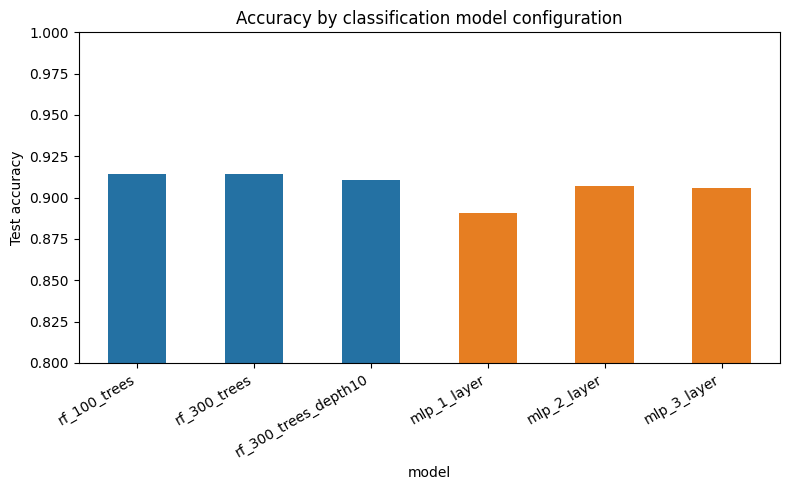

In [24]:
colors = ['#2471a3' if t == 'Random Forest' else '#e67e22' for t in classification_results_df['type']]
ax = classification_results_df['accuracy'].plot(kind='bar', color=colors, figsize=(8, 5))
plt.ylabel('Test accuracy')
plt.title('Accuracy by classification model configuration')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Every random forest configuration outperforms every multilayer perceptron configuration on accuracy, precision, recall and F1. The best configuration of each model type is carried forward for a closer look: a confusion matrix for each, and a feature importance ranking from the random forest.

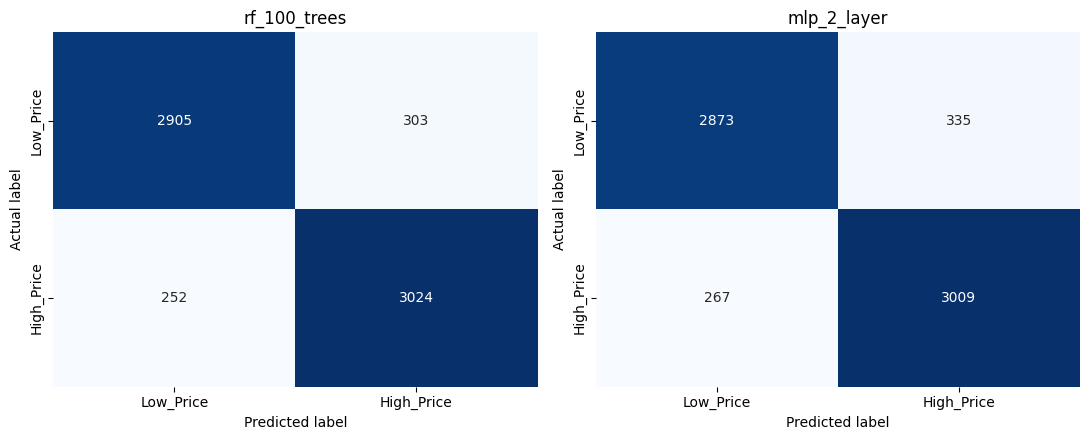

In [25]:
best_rf_name = classification_results_df[classification_results_df['type'] == 'Random Forest']['accuracy'].idxmax()
best_mlp_name = classification_results_df[classification_results_df['type'] == 'Neural Network']['accuracy'].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, [best_rf_name, best_mlp_name]):
    cm = confusion_matrix(y_test, classification_predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Low_Price', 'High_Price'], yticklabels=['Low_Price', 'High_Price'])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')
    ax.set_title(name)
plt.tight_layout()
plt.show()

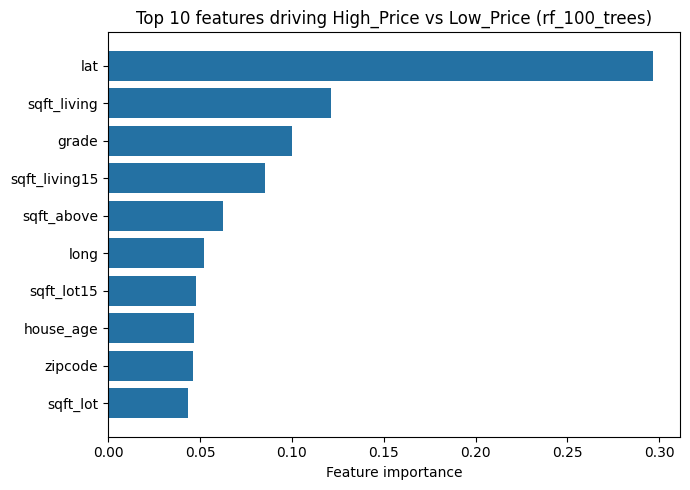

In [26]:
importances = pd.Series(classification_models[best_rf_name].feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(7, 5))
plt.barh(importances.index, importances.values, color='#2471a3')
plt.xlabel('Feature importance')
plt.title(f'Top 10 features driving High_Price vs Low_Price ({best_rf_name})')
plt.tight_layout()
plt.show()

<a id = "cell_report"></a>
## 4. Experiments Report

**Part A: price estimation.** Linear regression and three neural network configurations were evaluated on the same 70/30 train and test split of the King County sales data. Linear regression produced a mean absolute error of roughly $125,000 and an R squared of 0.69. All three neural networks beat this baseline, which is what the varied inputs and nonlinear activation functions inside a network are designed to capture. Among the three, `nn_wide_tanh` (100 tanh units followed by 80 relu units, trained with RMSprop) gave the lowest error, at roughly $80,000, and the highest R squared, at 0.85. `nn_deep_dropout`, the deepest network with regularisation, came second with a mean absolute error near $98,300, and `nn_shallow`, the smallest network, came third at roughly $105,000. This ordering suggests that width and a mixed activation setup mattered more for this data set than adding depth and dropout, at least within the range of settings tested here.

The practical reading of these numbers is that a straight line model misses interaction effects that matter in this housing market, for example how the value of extra living area changes with location or construction grade. A tuned neural network captures more of that structure and would give a real estate business a materially tighter price estimate to start a conversation with a seller or buyer, though a mean absolute error of around $80,000 is still large in absolute terms and any estimate from this model should be treated as a starting point rather than a final valuation.

**Part B: price band classification.** The price threshold of $450,000 splits the data set into 10,921 High_Price sales and 10,692 Low_Price sales, a close to even split that makes accuracy a reasonable headline metric alongside precision and recall. Three random forest settings and three multilayer perceptron settings were compared. Every random forest setting scored higher than every neural network setting on all four metrics tracked here. The best random forest, 100 trees with no depth limit, reached 91.4% accuracy, 90.9% precision and 92.3% recall. The best multilayer perceptron, with two hidden layers of 100 and 50 units, reached 90.7% accuracy. Restricting the random forest to 300 trees at a maximum depth of 10 slightly reduced accuracy compared to the unlimited depth settings, which suggests the extra depth is capturing genuine structure in the data rather than just overfitting noise, at least at this sample size.

Random forest also exposes a feature importance ranking that a neural network does not give directly. Latitude, living area and the King County grade score are the three strongest predictors of whether a house lands above or below the price threshold, followed by the living area of the 15 nearest homes and the above ground square footage. That ranking gives a real estate business something more than a label. It offers a way to explain a High_Price or Low_Price classification to a client in terms of the attributes actually driving it.

**Overall.** Both parts of this experiment reach the same qualitative conclusion from different angles: nonlinear models outperform simpler linear or shallow alternatives on this housing data set, and testing more than one configuration of each model type was worth the extra runtime, since the best setting was not always the most complex one. For deployment, a sensible pairing would be the tuned neural network for a first price estimate, together with the random forest classifier and its feature importance ranking to flag whether a listing sits in the higher price band and why. Two natural next steps for a production version of this work would be encoding zipcode as a categorical feature rather than a raw number, since location clearly matters more than its numeric correlation with price suggests, and testing whether gradient boosted trees can close the remaining gap with the neural network on the regression task.